# GNN Embedding Visualization & Anomaly Clustering with t-SNE

This notebook trains four GNN architectures (**GCN**, **GraphSAGE**, **GIN**, **DGI**) across **Cora** (node-level) and **Enzymes** (graph-level) tasks, extracts their high-dimensional representation embeddings, and projects them into 2D space using **t-SNE** (t-Distributed Stochastic Neighbor Embedding).

For each dataset and model, we compare two visual aspects:
1. **Class Clusters**: How well the GNN structures are organized relative to class labels.
2. **Anomaly Distributions**: Where the Isolation Forest outliers and DGI discriminator outliers are situated in the embedding space (typically at cluster boundaries or scattered regions).

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from torch_geometric.loader import DataLoader

from main import load_dataset, build_model, set_seed
from train import train_one_epoch, train_dgi_pretrain, train_dgi_pretrain_graph
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


## Helpers for Training & Embedding Extraction

In [2]:
def train_and_embed(model_name, dataset_name, epochs=60):
    """Train a GNN model and extract final representations and labels."""
    set_seed(42)
    
    data_params = DataParams(dataset_name=dataset_name, seed=42)
    ds_info = load_dataset(data_params)
    task = ds_info['task']
    
    model_params = ModelParams(model_name=model_name, hidden_channels=64, num_layers=2, dropout=0.5)
    model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], task).to(DEVICE)
    
    # Load loaders/data
    if task == 'node':
        data = ds_info['data'].to(DEVICE)
        train_mask = ds_info['train_mask'].to(DEVICE)
        val_mask = ds_info['val_mask'].to(DEVICE)
        
        # Train
        if model_name == 'dgi':
            pre_opt = torch.optim.Adam(model.parameters(), lr=0.01)
            for _ in range(120):
                train_dgi_pretrain(model, data, pre_opt)
            for param in model.dgi.encoder.parameters():
                param.requires_grad = False
            model.dgi.weight.requires_grad = False
            optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.01)
        else:
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
            
        best_val = 0.0
        best_state = None
        for _ in range(epochs):
            train_one_epoch(model, 'node', optimizer, DEVICE, data=data, train_mask=train_mask)
            val_acc = evaluate(model, 'node', DEVICE, data=data, mask=val_mask)['accuracy']
            if val_acc > best_val:
                best_val = val_acc
                best_state = {k: v.cpu() for k, v in model.state_dict().items()}
                
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
        emb = model.embed(data.x, data.edge_index).cpu().numpy()
        labels = data.y.cpu().numpy()
        
    else:
        # Graph task (Enzymes)
        train_loader = DataLoader(ds_info['train_dataset'], batch_size=32, shuffle=True)
        val_loader = DataLoader(ds_info['val_dataset'], batch_size=32, shuffle=False)
        
        full_dataset = list(ds_info['train_dataset']) + list(ds_info['val_dataset']) + list(ds_info['test_dataset'])
        full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False)
        
        if model_name == 'dgi':
            pre_opt = torch.optim.Adam(model.parameters(), lr=0.01)
            for _ in range(120):
                train_dgi_pretrain_graph(model, train_loader, pre_opt, DEVICE)
            for param in model.dgi.encoder.parameters():
                param.requires_grad = False
            model.dgi.weight.requires_grad = False
            optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.01)
        else:
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
            
        best_val = 0.0
        best_state = None
        for _ in range(epochs):
            train_one_epoch(model, 'graph', optimizer, DEVICE, train_loader=train_loader)
            val_acc = evaluate(model, 'graph', DEVICE, loader=val_loader)['accuracy']
            if val_acc > best_val:
                best_val = val_acc
                best_state = {k: v.cpu() for k, v in model.state_dict().items()}
                
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
        
        # Extract graph-level embeddings for all graphs
        model.eval()
        embs_list, labels_list = [], []
        with torch.no_grad():
            for batch in full_loader:
                batch = batch.to(DEVICE)
                z = model.embed(batch.x, batch.edge_index, batch.batch)
                embs_list.append(z.cpu().numpy())
                labels_list.append(batch.y.cpu().numpy())
        emb = np.vstack(embs_list)
        labels = np.concatenate(labels_list)
        
    return emb, labels

## Extract Node Embeddings on Cora and compute t-SNE

In [3]:
cora_results = {}
for model_name in ['gcn', 'graphsage', 'gin', 'dgi']:
    print(f'Extracting Cora embeddings for {model_name.upper()}...')
    emb, labels = train_and_embed(model_name, 'cora')
    
    # Add robust jitter to prevent zero-variance features
    emb = emb + np.random.normal(0, 1e-6, emb.shape)
    
    # Compute t-SNE
    tsne = TSNE(n_components=2, init='random', random_state=42)
    emb_2d = tsne.fit_transform(emb)
    
    # Compute Isolation Forest Anomaly Score
    iso = IsolationForest(contamination=0.1, random_state=42)
    iso.fit(emb)
    anomaly_scores = -iso.score_samples(emb)
    
    cora_results[model_name] = {
        'emb_2d': emb_2d,
        'labels': labels,
        'anomaly_scores': anomaly_scores
    }

Extracting Cora embeddings for GCN...


Extracting Cora embeddings for GRAPHSAGE...


Extracting Cora embeddings for GIN...


Extracting Cora embeddings for DGI...


## Plot Cora Cluster & Anomaly Scatter Map

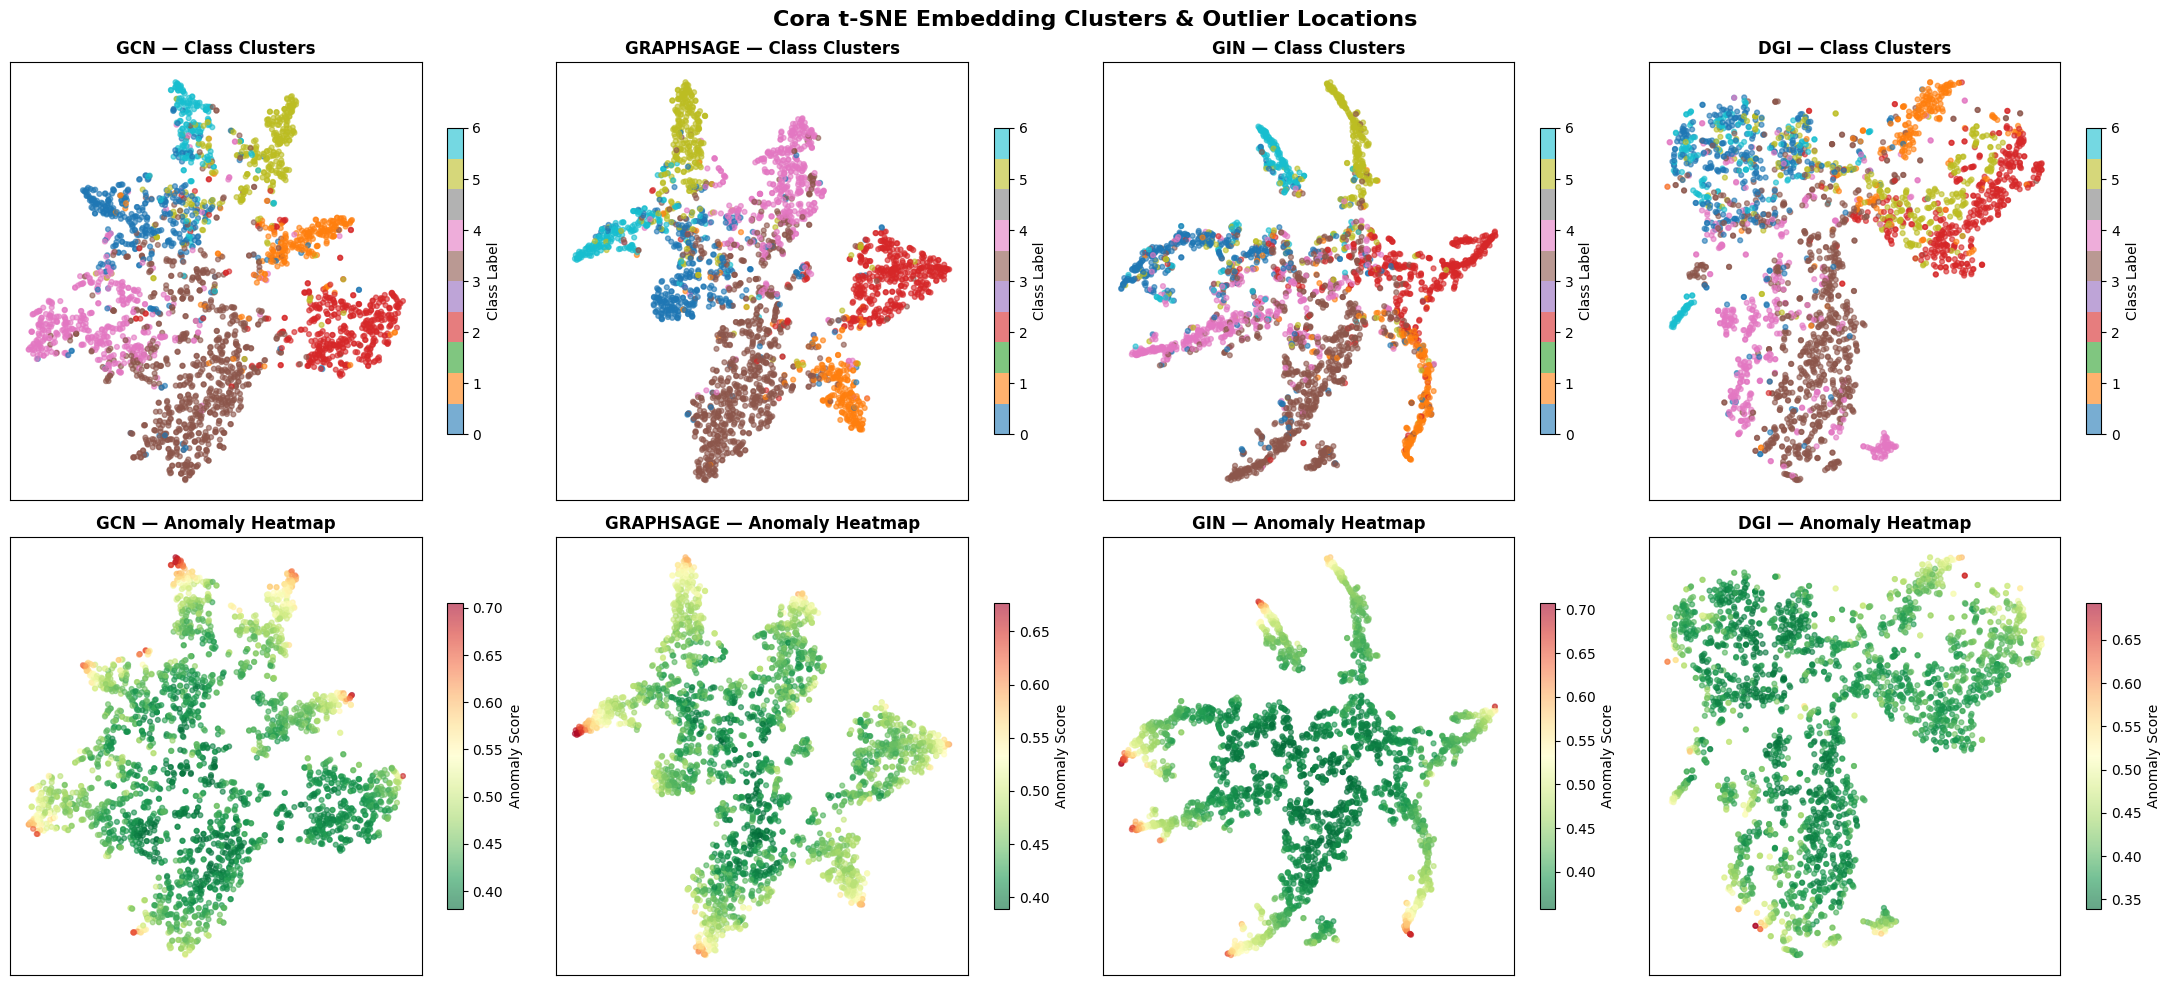

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
models_list = ['gcn', 'graphsage', 'gin', 'dgi']

for i, model_name in enumerate(models_list):
    res = cora_results[model_name]
    coords = res['emb_2d']
    
    # Top Row: Colored by target class labels
    ax_cls = axes[0, i]
    sc_cls = ax_cls.scatter(coords[:, 0], coords[:, 1], c=res['labels'], cmap='tab10', alpha=0.6, s=12)
    ax_cls.set_title(f'{model_name.upper()} — Class Clusters', fontweight='bold')
    ax_cls.grid(True, alpha=0.2)
    ax_cls.set_xticks([])
    ax_cls.set_yticks([])
    
    # Bottom Row: Colored by Isolation Forest Anomaly Score
    ax_anom = axes[1, i]
    sc_anom = ax_anom.scatter(coords[:, 0], coords[:, 1], c=res['anomaly_scores'], cmap='RdYlGn_r', alpha=0.6, s=12)
    ax_anom.set_title(f'{model_name.upper()} — Anomaly Heatmap', fontweight='bold')
    ax_anom.grid(True, alpha=0.2)
    ax_anom.set_xticks([])
    ax_anom.set_yticks([])
    
    # Add colorbars for each model
    fig.colorbar(sc_cls, ax=ax_cls, shrink=0.7, label='Class Label')
    fig.colorbar(sc_anom, ax=ax_anom, shrink=0.7, label='Anomaly Score')

plt.suptitle('Cora t-SNE Embedding Clusters & Outlier Locations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_cora_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Extract Graph Embeddings on Enzymes and compute t-SNE

In [5]:
enz_results = {}
for model_name in ['gcn', 'graphsage', 'gin', 'dgi']:
    print(f'Extracting Enzymes embeddings for {model_name.upper()}...')
    emb, labels = train_and_embed(model_name, 'enzymes')
    
    # Add robust jitter to prevent zero-variance features
    emb = emb + np.random.normal(0, 1e-6, emb.shape)
    
    # Compute t-SNE
    tsne = TSNE(n_components=2, init='random', random_state=42)
    emb_2d = tsne.fit_transform(emb)
    
    # Compute Isolation Forest Anomaly Score
    iso = IsolationForest(contamination=0.1, random_state=42)
    iso.fit(emb)
    anomaly_scores = -iso.score_samples(emb)
    
    enz_results[model_name] = {
        'emb_2d': emb_2d,
        'labels': labels,
        'anomaly_scores': anomaly_scores
    }

Extracting Enzymes embeddings for GCN...


Extracting Enzymes embeddings for GRAPHSAGE...


Extracting Enzymes embeddings for GIN...


Extracting Enzymes embeddings for DGI...


## Plot Enzymes Cluster & Anomaly Scatter Map

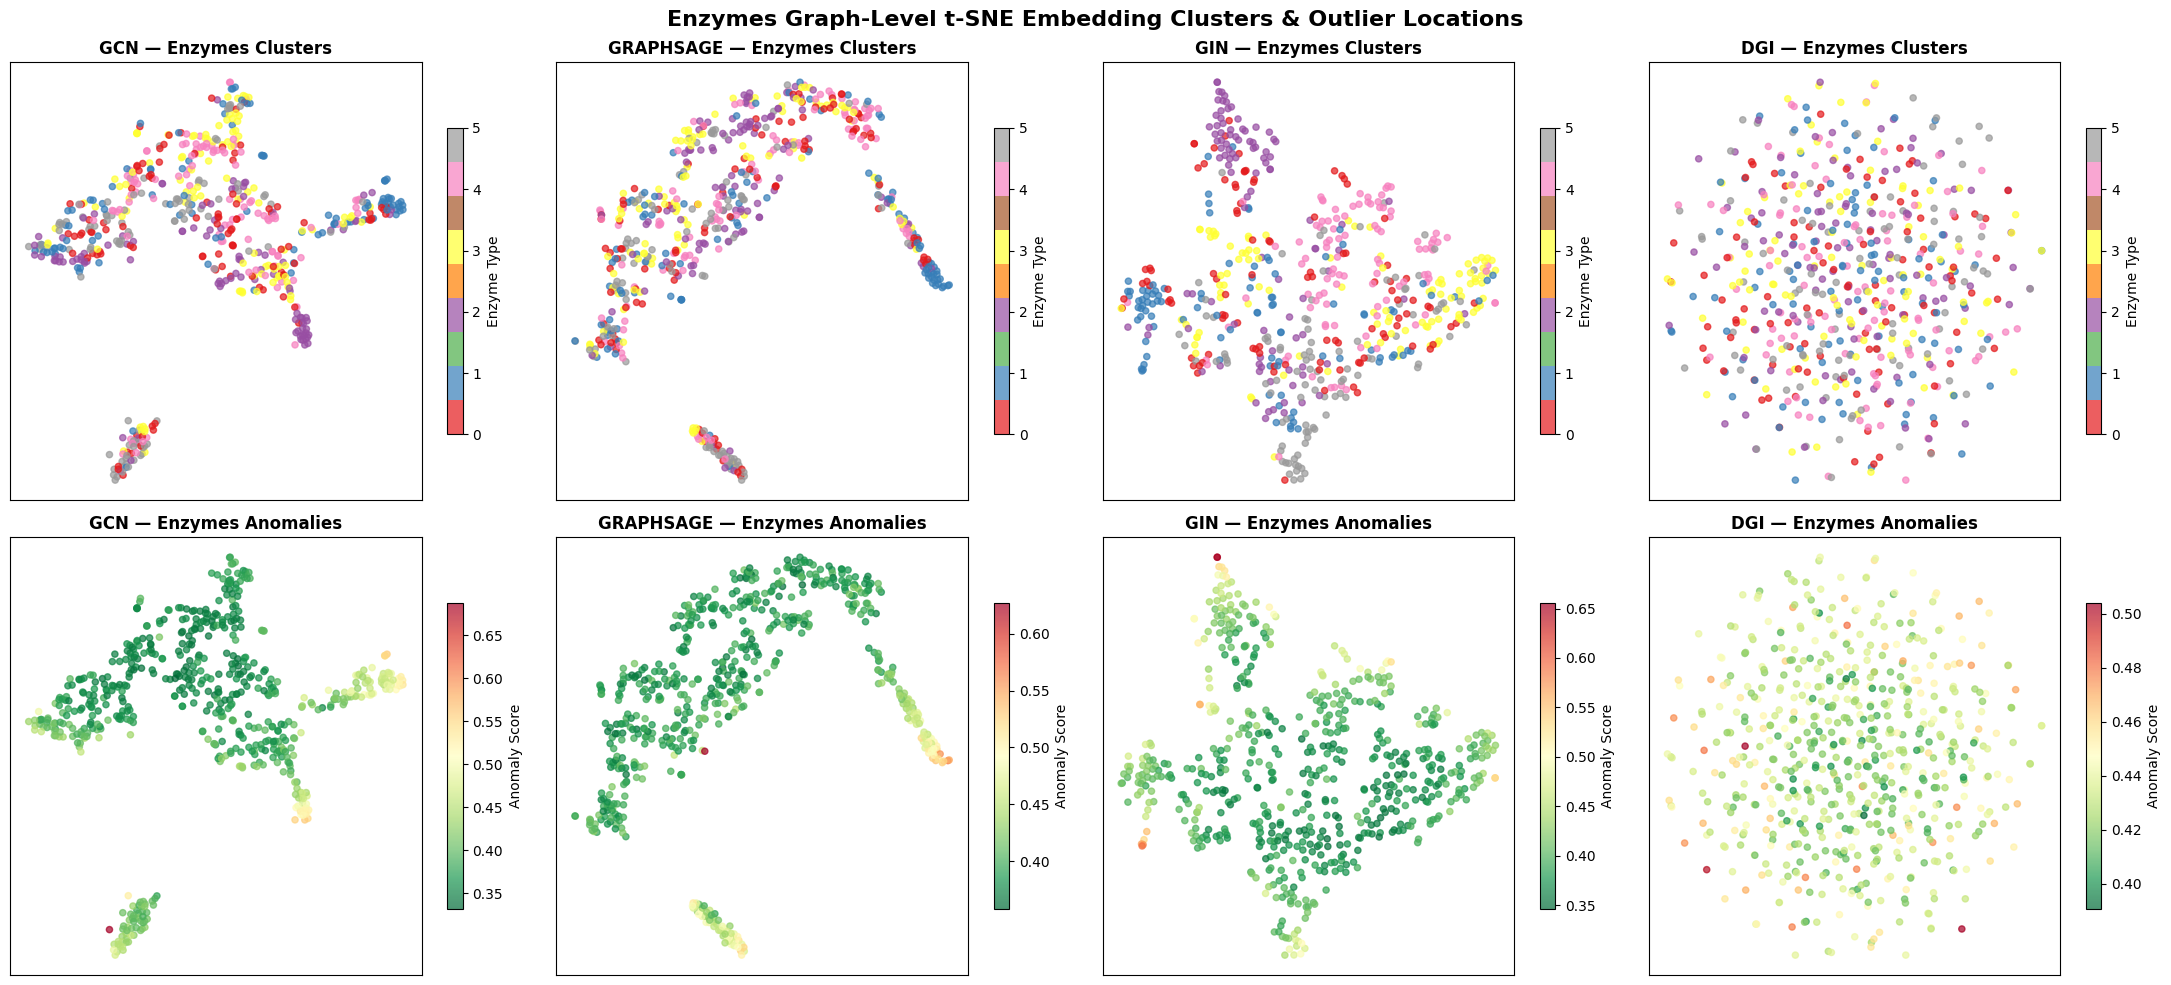

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for i, model_name in enumerate(models_list):
    res = enz_results[model_name]
    coords = res['emb_2d']
    
    # Top Row: Colored by target class labels
    ax_cls = axes[0, i]
    sc_cls = ax_cls.scatter(coords[:, 0], coords[:, 1], c=res['labels'], cmap='Set1', alpha=0.7, s=20)
    ax_cls.set_title(f'{model_name.upper()} — Enzymes Clusters', fontweight='bold')
    ax_cls.grid(True, alpha=0.2)
    ax_cls.set_xticks([])
    ax_cls.set_yticks([])
    
    # Bottom Row: Colored by Isolation Forest Anomaly Score
    ax_anom = axes[1, i]
    sc_anom = ax_anom.scatter(coords[:, 0], coords[:, 1], c=res['anomaly_scores'], cmap='RdYlGn_r', alpha=0.7, s=20)
    ax_anom.set_title(f'{model_name.upper()} — Enzymes Anomalies', fontweight='bold')
    ax_anom.grid(True, alpha=0.2)
    ax_anom.set_xticks([])
    ax_anom.set_yticks([])
    
    # Add colorbars for each model
    fig.colorbar(sc_cls, ax=ax_cls, shrink=0.7, ticks=range(6), label='Enzyme Type')
    fig.colorbar(sc_anom, ax=ax_anom, shrink=0.7, label='Anomaly Score')

plt.suptitle('Enzymes Graph-Level t-SNE Embedding Clusters & Outlier Locations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_enzymes_analysis.png', dpi=120, bbox_inches='tight')
plt.show()